<a href="https://colab.research.google.com/github/prathuskumarreddy/all-tasks/blob/main/BoneFractureprediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Bone Fracture detection using deeplearning

In [ ]:
!pip install opendatasets

In [ ]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/umeradnaan/x-ray-dection")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: harsha16112003
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/umeradnaan/x-ray-dection


100%|██████████| 173M/173M [00:01<00:00, 167MB/s]


In [ ]:
import pickle
import cv2
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import os
import random
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import numpy as np

In [ ]:
Directory = "/content/x-ray-dection/Bone Fracture Dataset/training"
categories =["fractured","not_fractured"]

In [ ]:
Image_size = 128
data = []

for category in categories:
  folders = os.path.join(Directory,category)
  label = categories.index(category)
  print(f"{category}:",label)

  for img in os.listdir(folders):
    img_path = os.path.join(folders,img)
    img_arr = cv2.imread(img_path)
    if img_arr is not None:
        img_arr_resize = cv2.resize(img_arr,(Image_size,Image_size))
        data.append([img_arr_resize,label])

fractured: 0
not_fractured: 1


In [ ]:
len(data)

8863

In [ ]:
random.shuffle(data)

In [ ]:
random.shuffle(data)

In [ ]:
type(data[0])

list

In [ ]:
data[0]

[array([[[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        ...,
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]]], dtype=uint8),
 1]

In [ ]:
x = []
y = []

for features,labels in data:
  x.append(features)
  y.append(labels)

In [ ]:
len(x)

8863

In [ ]:
len(y)

8863

In [ ]:
x = np.array(x, dtype='uint8')
y = np.array(y)
import gc
del data
gc.collect()

0

In [ ]:
print(x)

[[[[ 0  0  0]
   [ 0  0  0]
   [ 0  0  0]
   ...
   [ 0  0  0]
   [ 0  0  0]
   [ 0  0  0]]

  [[ 0  0  0]
   [ 0  0  0]
   [ 0  0  0]
   ...
   [ 0  0  0]
   [ 0  0  0]
   [ 0  0  0]]

  [[ 0  0  0]
   [ 0  0  0]
   [ 0  0  0]
   ...
   [ 0  0  0]
   [ 0  0  0]
   [ 0  0  0]]

  ...

  [[ 0  0  0]
   [ 0  0  0]
   [ 0  0  0]
   ...
   [ 0  0  0]
   [ 0  0  0]
   [ 0  0  0]]

  [[ 0  0  0]
   [ 0  0  0]
   [ 0  0  0]
   ...
   [ 0  0  0]
   [ 0  0  0]
   [ 0  0  0]]

  [[ 0  0  0]
   [ 0  0  0]
   [ 0  0  0]
   ...
   [ 0  0  0]
   [ 0  0  0]
   [ 0  0  0]]]


 [[[ 0  0  0]
   [ 0  0  0]
   [ 0  0  0]
   ...
   [ 0  0  0]
   [ 0  0  0]
   [ 0  0  0]]

  [[ 0  0  0]
   [ 0  0  0]
   [ 0  0  0]
   ...
   [ 0  0  0]
   [ 0  0  0]
   [ 0  0  0]]

  [[ 0  0  0]
   [ 0  0  0]
   [ 0  0  0]
   ...
   [ 0  0  0]
   [ 0  0  0]
   [ 0  0  0]]

  ...

  [[ 0  0  0]
   [ 0  0  0]
   [ 0  0  0]
   ...
   [ 0  0  0]
   [ 0  0  0]
   [ 0  0  0]]

  [[ 0  0  0]
   [ 0  0  0]
   [ 0  0  0]
   ...
   [ 

In [ ]:
print(y)

[1 1 1 ... 1 0 1]


In [ ]:
len(x)

8863

In [ ]:
x.shape

(8863, 128, 128, 3)

In [ ]:
y.shape

(8863,)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
x_train.shape

(7090, 128, 128, 3)

In [ ]:
y_train.shape

(7090,)

In [ ]:
x_test.shape

(1773, 128, 128, 3)

In [ ]:
y_test.shape

(1773,)

In [ ]:
#!pip install tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense

In [ ]:
cnn = Sequential()
cnn.add(Conv2D(filters=64,kernel_size=(3,3),padding="same",activation="relu",input_shape=(128,128,3)))
cnn.add(MaxPooling2D(2,2))
cnn.add(Conv2D(filters=32,kernel_size=(3,3),padding="same",activation="relu"))
cnn.add(MaxPooling2D(2,2))
cnn.add(Dropout(0.2))
cnn.add(Flatten())
cnn.add(Dense(256,activation="relu"))
cnn.add(Dense(2,activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,409,634 (32.08 MB)

 Trainable params: 8,409,634 (32.08 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cnn.compile(optimizer="adam",
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"])

In [ ]:
history = cnn.fit(x,y,epochs=10,validation_split=0.1)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.5838 - loss: 3.8210 - val_accuracy: 0.5862 - val_loss: 0.6518
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.6488 - loss: 0.6096 - val_accuracy: 0.7215 - val_loss: 0.5399
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.7319 - loss: 0.5688 - val_accuracy: 0.7926 - val_loss: 0.4157
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.8386 - loss: 0.3567 - val_accuracy: 0.8298 - val_loss: 0.3481
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.9086 - loss: 0.2158 - val_accuracy: 0.8884 - val_loss: 0.2912
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.9371 - loss: 0.1601 - val_accuracy: 0.9335 - val_loss: 0.2092
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.9590 - loss: 0.1112 - val_accuracy: 0.9290 - val_loss: 0.2244
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.9709 - loss: 0.0775 - val_acc

In [ ]:
loss,accuracy = cnn.evaluate(x_test,y_test)
print("Test accuracy:",accuracy)

56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9949 - loss: 0.0183
Test accuracy: 0.9949238300323486


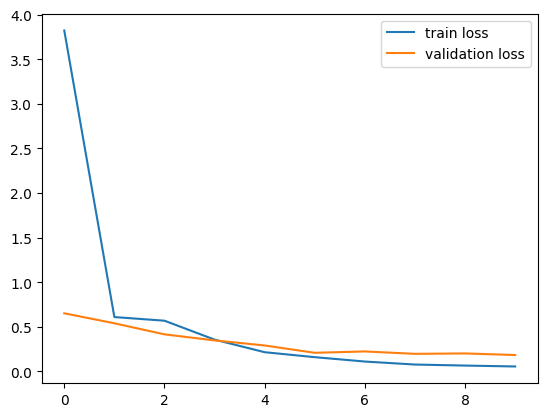

In [ ]:
plt.plot(history.history["loss"],label="train loss")
plt.plot(history.history["val_loss"],label="validation loss")
plt.legend()
plt.show()

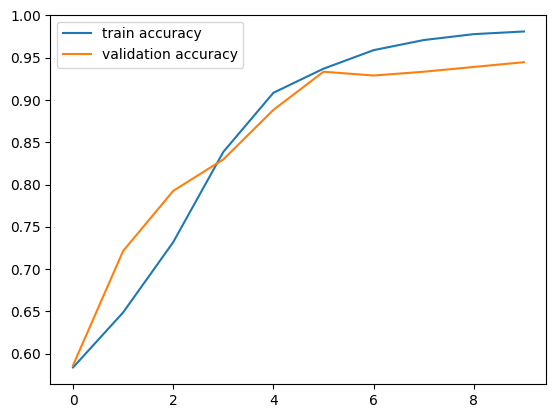

In [ ]:
plt.plot(history.history["accuracy"],label="train accuracy")
plt.plot(history.history["val_accuracy"],label="validation accuracy")
plt.legend()
plt.show()

In [ ]:
pred=cnn.predict(x_test)

56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


In [ ]:
pred

array([[9.0734512e-01, 9.2654854e-02],
       [9.9980593e-01, 1.9406433e-04],
       [1.0000000e+00, 2.7827723e-10],
       ...,
       [3.3898540e-03, 9.9661011e-01],
       [9.9999869e-01, 1.3153298e-06],
       [9.9999988e-01, 1.2365440e-07]], dtype=float32)

In [ ]:
index=[np.argmax(i) for i in pred]

In [ ]:
new_dataframe = pd.DataFrame({"actual":y_test,"predict":index})
print(new_dataframe)

      actual  predict
0          0        0
1          0        0
2          0        0
3          1        1
4          0        0
...      ...      ...
1768       1        1
1769       1        1
1770       1        1
1771       0        0
1772       0        0

[1773 rows x 2 columns]


# PREDICTIVE SYSTEM FOR USER TO GIVE UNKNOWN X_RAY IMAGES FOR CLASSIFICATION

In [ ]:
import cv2
import numpy as np

# Loading and preprocessing the test image
test_path = '/content/x-ray-dection/Bone Fracture Dataset/testing/not_fractured/1-rotated1-rotated2-rotated1.jpg'
img = cv2.imread(test_path)

if img is not None:
    # Resize to Image_size (128) used during training
    img_resized = cv2.resize(img, (Image_size, Image_size))
    img_array = np.array(img_resized, dtype='uint8')
    # Add batch dimension: (1, 128, 128, 3)
    img_array = np.expand_dims(img_array, axis=0)
    print('Image loaded and preprocessed successfully.')
else:
    print(f'Error: Image file not found at {test_path}.')

Image loaded and preprocessed successfully.


In [ ]:
from tensorflow.keras.preprocessing import image

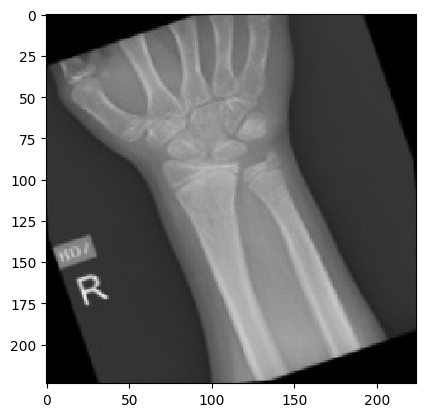

In [ ]:
img = image.load_img('/content/x-ray-dection/Bone Fracture Dataset/testing/not_fractured/1-rotated1-rotated2-rotated1.jpg')
plt.imshow(img,interpolation='nearest')
plt.show()

In [ ]:
a = cnn.predict(img_array)
indeces = a.argmax()
print(f"Prediction Index: {indeces}")

if indeces == 0:
    print("Result: It is a fractured human bone")
else:
    print("Result: It is not a fractured human bone")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 487ms/step
Prediction Index: 1
Result: It is not a fractured human bone


In [ ]:
from sklearn.metrics import classification_report,confusion_matrix

In [ ]:
print(classification_report(y_test,index))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       883
           1       0.99      1.00      0.99       890

    accuracy                           0.99      1773
   macro avg       0.99      0.99      0.99      1773
weighted avg       0.99      0.99      0.99      1773



In [ ]:
import seaborn as sns

In [ ]:
cn=confusion_matrix(y_test,index)

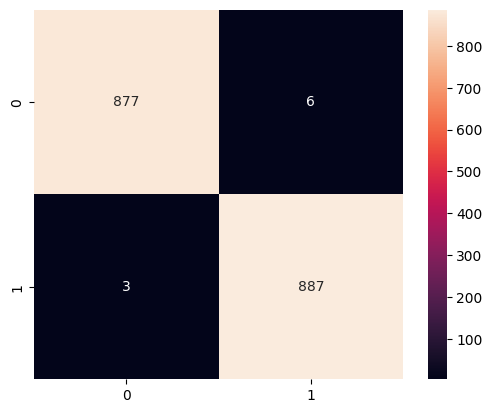

In [ ]:
sns.heatmap(cn,annot=True,square=True,fmt=".0f")
plt.show()

**END Of project**
